# Week 1: Gaia Stellar Data Exploration

**Goal:** Query real star data from the Gaia DR3 catalog, explore it raw, understand why cleaning matters, engineer features, and build the Hertzsprung-Russell (HR) diagram.

**What is Gaia?**  
A European Space Agency satellite that has measured the positions, distances, and brightness of ~1.8 billion stars. Data is queried live using ADQL — a dialect of SQL for astronomical archives.

**What is the HR Diagram?**  
A scatter plot of color (temperature proxy) vs. absolute magnitude (true brightness). Stars cluster into distinct sequences revealing their evolutionary stage:  
- **Main sequence** — stars fusing hydrogen (like our Sun)  
- **Red giant branch** — stars that have exhausted their core hydrogen  
- **White dwarfs** — dense stellar remnants, hot but dim  

---
**Flow:** `Install → Import → Query → Raw Explore → Clean → Feature Engineering → Visualize`

## Imports

All imports in one place — run this before any other cell.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.data_fetch import fetch_gaia_sample
from src.data_clean import clean_sample, add_features
from src import visualize

Status messages could not be retrieved


## Step 1: Setup & Network Config

`astroquery` needs a higher timeout for the Gaia archive. The SSL override is a workaround for corporate network inspection that breaks the default certificate chain — it disables verification for this session.

In [2]:
import ssl
import astropy.utils.data as aud

aud.REMOTE_TIMEOUT = 60
# Disable SSL verification — workaround for corporate network inspection
ssl._create_default_https_context = ssl._create_unverified_context

## Step 2: Query the Gaia Archive

We fetch 10,000 stars from `gaiadr3.gaia_source` using ADQL.

| Column | Meaning |
|--------|---------|
| `parallax` | Angular shift in milliarcseconds — used to compute distance |
| `parallax_error` | Measurement uncertainty on parallax |
| `phot_g_mean_mag` | Apparent brightness in the G (green) band |
| `bp_rp` | Color index (Blue − Red). Low = hot/blue, high = cool/red |

In [3]:
df = fetch_gaia_sample(top_n=10000)
df.head()

/var/folders/nd/dn4_4gx943b24pgx_l763l100000gn/T/ipykernel_31911/3183202058.py:1: UserWarning: SSL certificate verification is disabled for this session. All HTTPS connections in this process will skip cert checks. Set SSL_CERT_FILE to your corporate CA bundle to avoid this.
  df = fetch_gaia_sample(top_n=10000)


,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,pmra,pmdec
0,137333365999306624,45.003085,35.314218,0.225618,0.363590,19.339882,1.566929,2.311110,-0.480607
1,137337626604785664,45.241582,35.382075,-0.382525,0.771648,20.338495,1.992456,1.360268,-1.293220
2,137339486325672704,45.107517,35.339910,0.760605,0.333740,16.986778,1.231490,6.094735,-3.408876
3,137340375383849472,45.147666,35.377284,-1.471581,0.604335,20.067802,0.792685,1.161430,0.649128
4,137340718981261568,45.246634,35.412483,0.554473,0.190120,18.530119,1.571159,4.273933,-0.819983


## Step 3: Raw Exploration — Spot the Problems

Before cleaning, compute distance naively to see what goes wrong.  
`distance_pc = 1000 / parallax_mas` — but some parallax values are negative (noise artifact on very distant stars), giving **unphysical negative distances**:

In [4]:
df["distance_pc"] = 1000 / df["parallax"]
df["distance_pc"]

0        4432.276828
1       -2614.208700
2        1314.742662
3        -679.541438
4        1803.515769
            ...     
9995    12319.329081
9996     1150.668041
9997     2950.987744
9998   -13403.906595
9999     1638.347564
Name: distance_pc, Length: 10000, dtype: float64

### Parallax Distribution (raw)

Notice the negative tail on the left — these are the measurement noise artifacts we need to remove:

<Axes: >

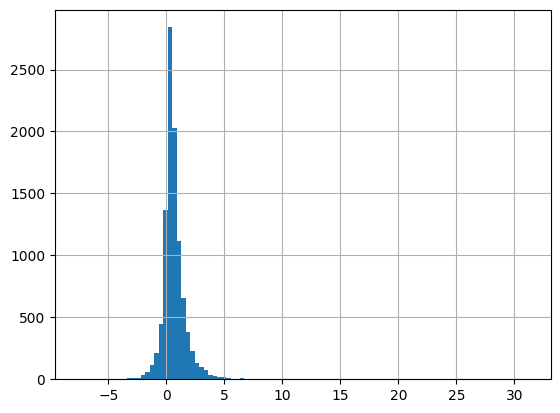

In [5]:
df["parallax"].hist(bins=100)

### Labeled Parallax Histogram

Same plot with proper axis labels — most stars cluster at small parallax (distant), with a tail of nearby bright stars at high values:

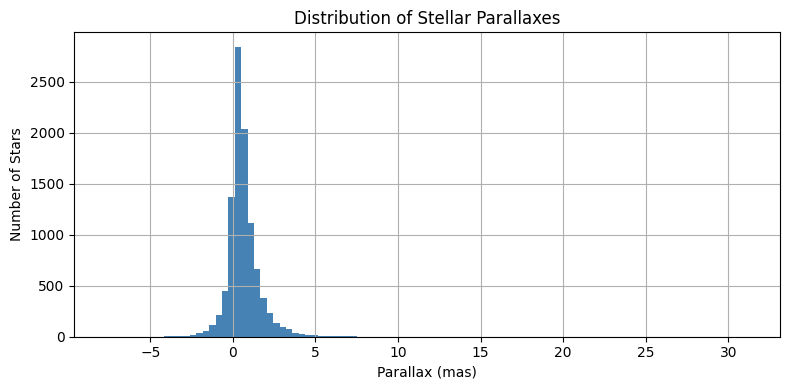

In [6]:
visualize.plot_parallax_hist(df)

### Log-Scale Parallax Histogram

Same data on a **log y-axis** — makes rare high-parallax stars (nearby) visible alongside the dense bulk of distant stars. Without log scale, the tall distant-star bar crushes everything else.

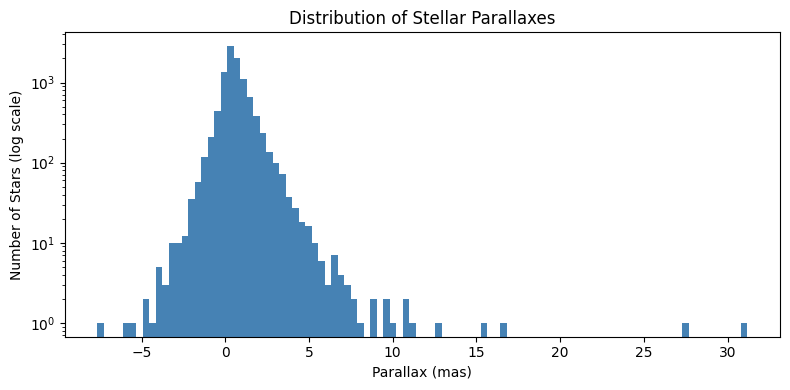

In [7]:
visualize.plot_parallax_hist_log(df)

## Step 4: Clean the Data

Three quality filters — each targets a specific class of bad measurement:

| Filter | Removes | Why |
|--------|---------|-----|
| `parallax > 0` | Negative parallax | Unphysical — gives negative distance |
| `parallax / parallax_error > 5` | Low signal-to-noise stars | Distance uncertainty > 25% → absolute magnitude unreliable |
| `bp_rp` not null | Stars with no color | Can't be placed on the HR diagram |

In [8]:
clean = clean_sample(df)

Stars before cleaning: 10,000
Stars after cleaning:  2,420  (24.2% kept)


## Step 5: Feature Engineering

Two derived columns needed for the HR diagram — neither exists in the raw Gaia data:

**Distance in parsecs:**  
`distance_pc = 1000 / parallax_mas`  
1 parsec ≈ 3.26 light-years. Parallax in milliarcseconds inverts directly.

**Absolute magnitude:**  
`M = m − 5 × log₁₀(d / 10)`  
The **distance modulus** — strips out distance so we compare true intrinsic stellar brightness. At d = 10 pc, M = m (the standard reference point).

In [9]:
clean = add_features(clean)
print(clean[["bp_rp", "absolute_mag", "distance_pc"]].describe())

             bp_rp  absolute_mag  distance_pc
count  2420.000000   2420.000000  2420.000000
mean      1.576666      6.378281  1210.181392
std       0.628082      2.637287   896.676211
min       0.029331     -1.982372    32.058586
25%       1.103874      4.536826   603.613468
50%       1.354457      6.053688  1023.453008
75%       1.966013      8.150771  1560.836782
max       4.945676     14.982125  7839.898824


## Step 6: Visualize

### 6a. HR Diagram — Density Map

Hex-bin plot with log color scale reveals structure across orders of magnitude.  
**Y-axis inverted** — astronomy convention: bright (low magnitude) at top.

Look for:
- **Diagonal band** top-left → bottom-right → **main sequence**
- **Clump upper-right** (bright + red) → **red giants**
- **Sparse lower-left** (dim + blue/white) → **white dwarfs**

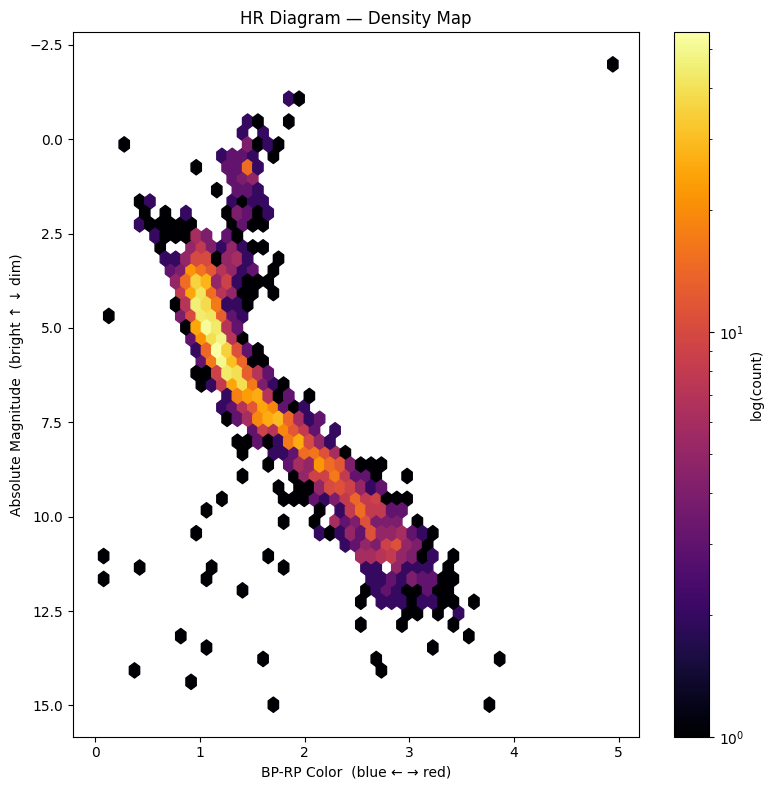

In [10]:
visualize.plot_hr_density(clean)

### 6a-ii. HR Diagram — Scatter Plot

Same data as the density map above but as a plain scatter plot — each dot is one star.  
Useful for spotting individual outliers and the overall population shape before density encoding hides detail.  
`s=1, alpha=0.5` keeps it readable at 10k points.

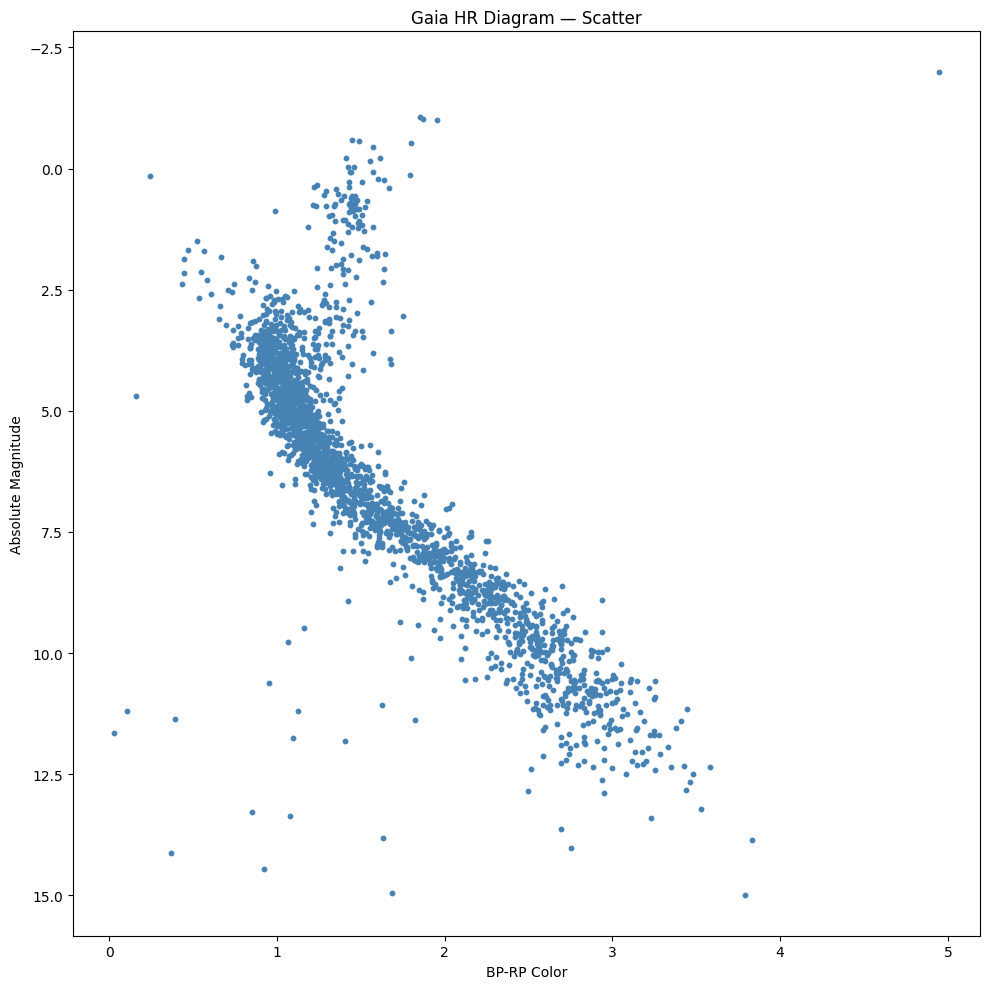

In [11]:
visualize.plot_hr_scatter(clean)

### 6b. Absolute Magnitude Distribution

Peak around M ≈ 4–6, dominated by main-sequence stars. Our Sun sits at M ≈ 4.83 — right in the middle.

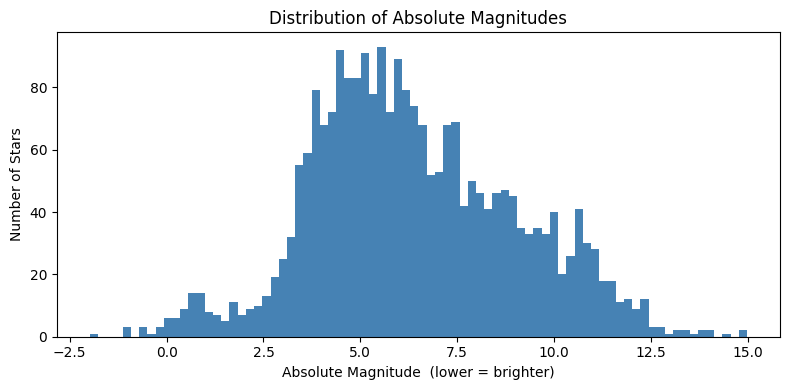

In [12]:
visualize.plot_abs_mag_hist(clean)

### 6c. Distance vs. Brightness — Malmquist Bias

At large distances only intrinsically bright stars are detectable above Gaia's flux limit. The **missing lower-right corner** (faint + far = invisible) makes this selection bias visible.

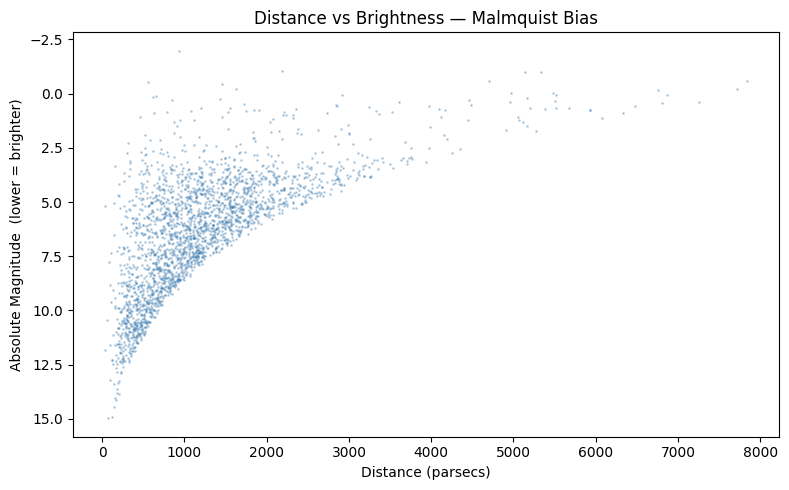

In [13]:
visualize.plot_distance_vs_mag(clean)

---

## Summary

| Step | What we did | Key insight |
|------|-------------|-------------|
| Query | 10k stars from Gaia DR3 via ADQL | Real observational data |
| Raw explore | Naive distance → negative values | Shows exactly why cleaning is necessary |
| Clean | Removed negative parallax, low-SNR, missing color | Each filter has a physical motivation |
| Features | `distance_pc` and `absolute_mag` | Distance modulus corrects for star distance |
| Visualize | HR diagram, magnitude hist, Malmquist plot | Sample biases are visible in the data |

**Next:** [`week2_kmeans_clustering.ipynb`](week2_kmeans_clustering.ipynb) — K-Means to recover stellar populations without labels.

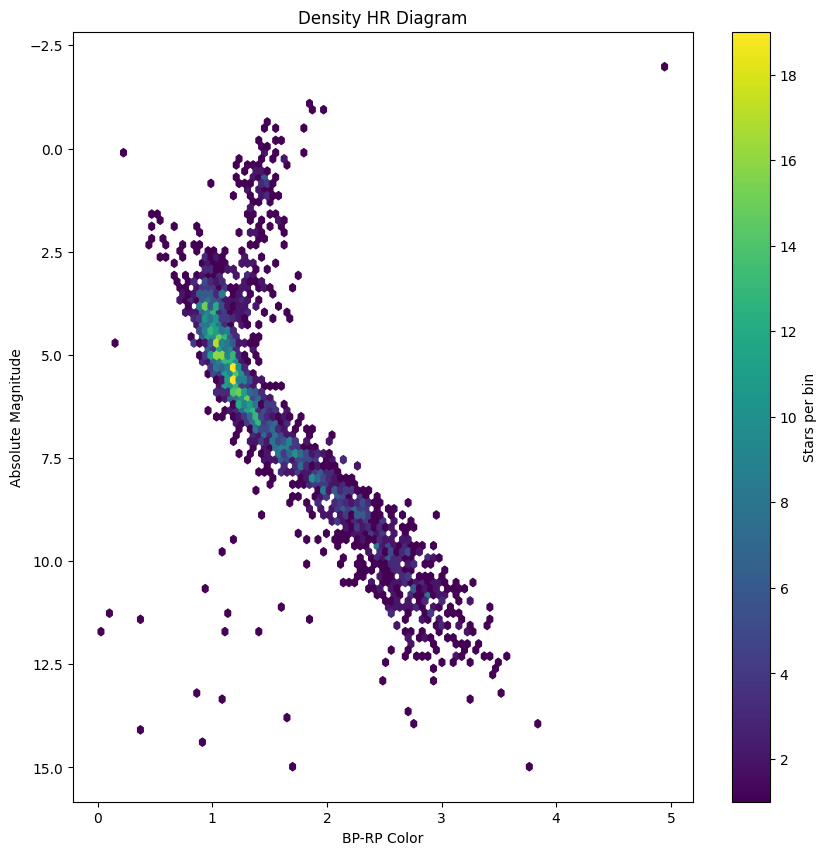

In [14]:
plt.figure(figsize=(10,10))

plt.hexbin(
    clean["bp_rp"],
    clean["absolute_mag"],
    gridsize=100,
    mincnt=1
)

plt.gca().invert_yaxis()

plt.xlabel("BP-RP Color")
plt.ylabel("Absolute Magnitude")
plt.title("Density HR Diagram")

plt.colorbar(label="Stars per bin")

plt.show()

In [15]:
weird = clean[
    (clean["bp_rp"] > 2.5) &
    (clean["absolute_mag"] < 2)
]

weird.head()

,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp,pmra,pmdec,distance_pc,absolute_mag
623,138831454885582336,46.14261,35.861704,1.076976,0.081029,7.856598,4.945676,-2.157229,-3.137261,928.525808,-1.982372


In [17]:
clean["ra"].head(500),clean["dec"].head(500),clean["pmra"].head(500),clean["pmdec"].head(500)

(5       45.252042
 8       45.189956
 11      44.881267
 13      44.909109
 18      44.910066
           ...    
 1995    45.928104
 2001    46.044227
 2009    45.415403
 2011    45.401034
 2012    45.460402
 Name: ra, Length: 500, dtype: float64,
 5       35.403773
 8       35.476358
 11      35.367909
 13      35.395708
 18      35.411084
           ...    
 1995    35.881436
 2001    35.924971
 2009    35.481396
 2011    35.502398
 2012    35.528159
 Name: dec, Length: 500, dtype: float64,
 5        6.185548
 8       -2.532635
 11       7.281375
 13      16.552442
 18      -0.786020
           ...    
 1995    11.279290
 2001     4.564485
 2009    -0.408384
 2011     0.384227
 2012     3.312018
 Name: pmra, Length: 500, dtype: float64,
 5       -1.330907
 8       -4.615308
 11      -9.747042
 13     -26.916252
 18      -0.529584
           ...    
 1995    -1.200449
 2001   -12.081192
 2009     0.517643
 2011    -4.270807
 2012   -11.019281
 Name: pmdec, Length: 500, dtype: float64

Text(0.5, 1.0, 'Stellar Proper Motions')

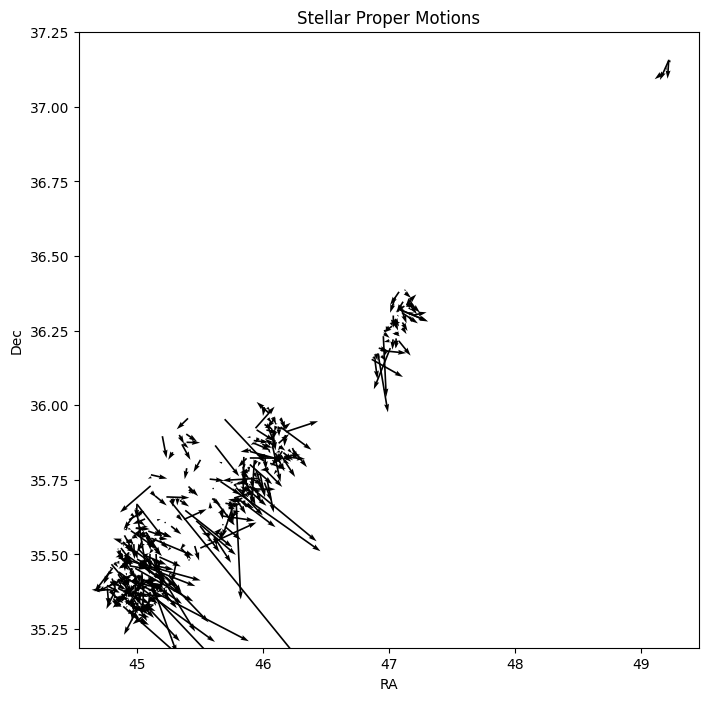

In [16]:
plt.figure(figsize=(8,8))

plt.quiver(
    clean["ra"].head(500),
    clean["dec"].head(500),
    clean["pmra"].head(500),
    clean["pmdec"].head(500)
)

plt.xlabel("RA")
plt.ylabel("Dec")
plt.title("Stellar Proper Motions")